<a href="https://colab.research.google.com/github/akshaykumar2972/Netflix-Data-Analysis/blob/main/Netflix_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing the data from local file

In [4]:
df = pd.read_csv('/content/dataset.csv').drop_duplicates()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df['added_date'] = pd.to_datetime(df['date_added'], format='mixed').dt.date

In [8]:
# Randomly compare 20 values to verify
print(df[['date_added','added_date']].sample(20))

              date_added  added_date
321       August 3, 2021  2021-08-03
1976  September 19, 2020  2020-09-19
4052       March 1, 2019  2019-03-01
3202    December 1, 2019  2019-12-01
7801       March 1, 2018  2018-03-01
2089     August 27, 2020  2020-08-27
1546   December 15, 2020  2020-12-15
3914      April 15, 2019  2019-04-15
417        July 22, 2021  2021-07-22
3051     January 1, 2020  2020-01-01
6917        June 6, 2020  2020-06-06
1632   November 30, 2020  2020-11-30
4512    October 12, 2018  2018-10-12
2762      March 28, 2020  2020-03-28
2910   February 15, 2020  2020-02-15
6706    January 14, 2017  2017-01-14
3010    January 17, 2020  2020-01-17
7816        July 1, 2019  2019-07-01
1153      March 29, 2021  2021-03-29
6228        June 4, 2018  2018-06-04


In [9]:
df['duration'].unique()

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [10]:
df['running_time'] = (pd.to_numeric(df['duration'].str.split(' ').str[0], errors='coerce').fillna(0).astype(int))

In [11]:
# Randomly compare 20 values to verify
print(df[['duration', 'running_time']].sample(20))

       duration  running_time
1651    115 min           115
7941     78 min            78
430    1 Season             1
5352   1 Season             1
4422    146 min           146
6815    106 min           106
1064   1 Season             1
5625     91 min            91
4044   1 Season             1
2663    144 min           144
3144    104 min           104
532   3 Seasons             3
2417  4 Seasons             4
2701    104 min           104
130      63 min            63
4155     86 min            86
3559     66 min            66
3877     64 min            64
3737   1 Season             1
3561  3 Seasons             3


In [12]:
df.drop(['date_added','duration', 'description'], axis=1, inplace=True)

In [13]:
df.describe()

,release_year,running_time
count,8807.000000,8807.000000
mean,2014.180198,69.823095
std,8.819312,50.822520
min,1925.000000,0.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2019.000000,106.000000
max,2021.000000,312.000000


In [14]:
df.describe(include='object')

,show_id,type,title,director,cast,country,rating,listed_in,added_date
count,8807,8807,8807,6173,7982,7976,8803,8807,8797
unique,8807,2,8807,4528,7692,748,17,514,1714
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,TV-MA,"Dramas, International Movies",2020-01-01
freq,1,6131,1,19,19,2818,3207,362,110


In [15]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'release_year', 'rating', 'listed_in', 'added_date', 'running_time'],
      dtype='object')

In [16]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
release_year,0
rating,4
listed_in,0
added_date,10


In [17]:
df.fillna({'director': 'Unknown', 'cast': 'Unknown', 'country': 'Unknown'}, inplace=True)

In [18]:
df.dropna(axis=0, inplace=True)

In [19]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
release_year,0
rating,0
listed_in,0
added_date,0


In [20]:
df.shape

(8793, 11)

In [21]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,Documentaries,2021-09-25,90
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",2021-09-24,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021,TV-MA,"Docuseries, Reality TV",2021-09-24,1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",2021-09-24,2


In [22]:
df[df['director'] != 'Unknown']['director'].value_counts().reset_index().head(10)

,director,count
0,Rajiv Chilaka,19
1,"Raúl Campos, Jan Suter",18
2,Marcus Raboy,16
3,Suhas Kadav,16
4,Jay Karas,14
5,Cathy Garcia-Molina,13
6,Martin Scorsese,12
7,Jay Chapman,12
8,Youssef Chahine,12
9,Steven Spielberg,11


**Most popular Movie stars**

In [23]:
cast_series = df[df['type'] == 'Movie']['cast'].str.split(',').explode().str.strip()
cast_series = cast_series[~cast_series.isin(['Unknown', ''])]
cast_series.value_counts().head(10).sort_values(ascending=False).reset_index().rename(columns={'cast': 'Actor', 'count': 'Count_of_Movies'})

,Actor,Count_of_Movies
0,Anupam Kher,42
1,Shah Rukh Khan,35
2,Naseeruddin Shah,32
3,Akshay Kumar,30
4,Om Puri,30
5,Paresh Rawal,28
6,Amitabh Bachchan,28
7,Julie Tejwani,28
8,Rupa Bhimani,27
9,Boman Irani,27


**Most popular TV stars**

In [24]:
cast_series = df[df['type'] == 'TV Show']['cast'].str.split(',').explode().str.strip()
cast_series = cast_series[~cast_series.isin(['Unknown', ''])]
cast_series.value_counts().head(10).sort_values(ascending=False).reset_index().rename(columns={'cast': 'Actor', 'count': 'Count_Of_TV_Shows'})

,Actor,Count_Of_TV_Shows
0,Takahiro Sakurai,25
1,Yuki Kaji,19
2,Junichi Suwabe,17
3,Daisuke Ono,17
4,Yuichi Nakamura,16
5,Ai Kayano,16
6,Jun Fukuyama,15
7,Yoshimasa Hosoya,15
8,David Attenborough,14
9,Kana Hanazawa,13


In [25]:
df[df['country'] != 'Unknown']['country'].value_counts().reset_index().head(10)

,country,count
0,United States,2812
1,India,972
2,United Kingdom,418
3,Japan,243
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


In [26]:
df['rating'].value_counts().reset_index()

,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


In [27]:
df[df['rating'].isin(['74 min', '84 min', '66 min'])]

,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017,74 min,Movies,2017-04-04,0
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2010,84 min,Movies,2016-09-16,0
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2015,66 min,Movies,2016-08-15,0


In [28]:
df.drop(df[df['rating'].isin(['74 min', '84 min', '66 min'])].index, inplace=True)

In [29]:
df['rating'].value_counts().reset_index()

,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


In [30]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,Documentaries,2021-09-25,90
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",2021-09-24,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021,TV-MA,"Docuseries, Reality TV",2021-09-24,1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",2021-09-24,2


<Axes: xlabel='running_time', ylabel='Count'>

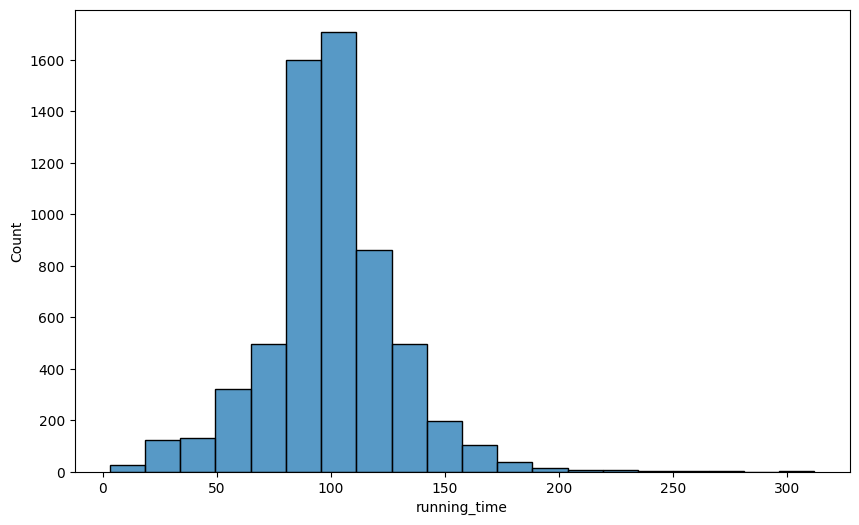

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(x='running_time', data=df[df['type']=='Movie'], bins=20)

<Axes: xlabel='running_time', ylabel='Count'>

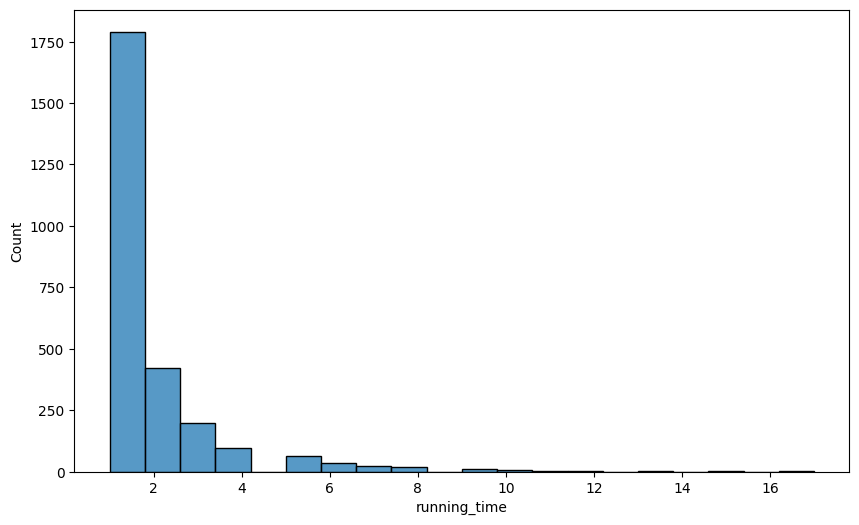

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(x='running_time', data=df[df['type']=='TV Show'], bins=20)

In [33]:
df['added_date'].nunique()

1713

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   listed_in     8790 non-null   object
 9   added_date    8790 non-null   object
 10  running_time  8790 non-null   int64 
dtypes: int64(2), object(9)
memory usage: 1.1+ MB


In [35]:
string = '2021-09-25'

In [43]:
df['added_date'] = pd.to_datetime(df['added_date'])
df['year_month'] = df['added_date'].dt.to_period('M')

In [58]:
all_counts = df.groupby(['year_month','type'])['show_id'].count().reset_index(name='count')
all_counts['year_month'] = all_counts['year_month'].dt.to_timestamp()

Text(0.5, 1.0, 'Total Movies and TV Shows Added Over Time')

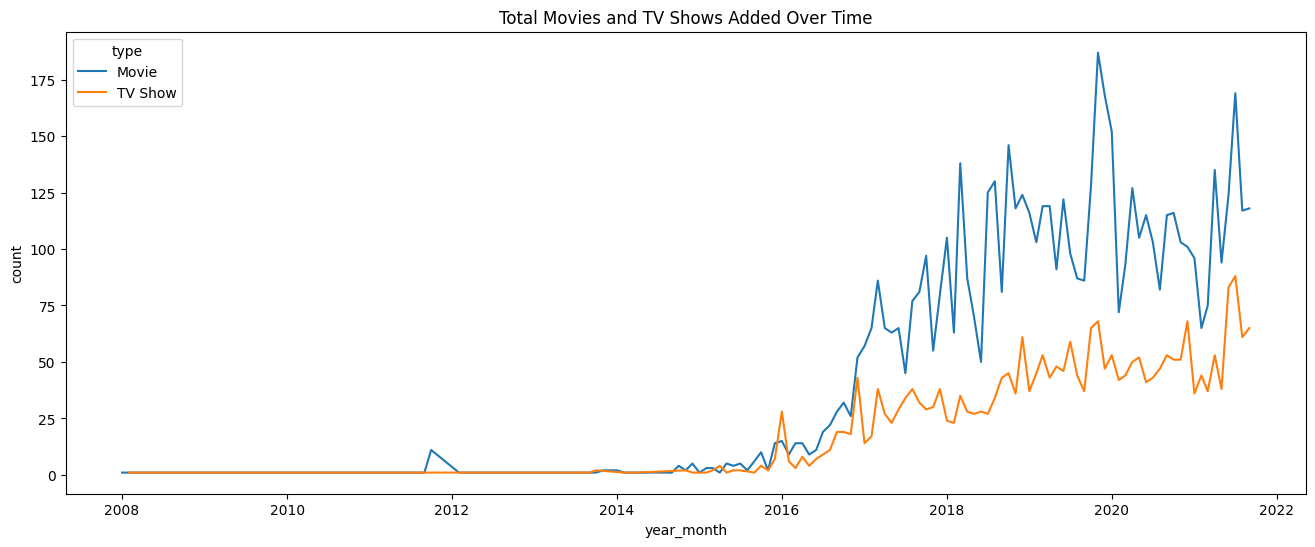

In [65]:
plt.figure(figsize=(16, 6))
sns.lineplot(x='year_month', y='count', data=all_counts, hue='type')
plt.title('Total Movies and TV Shows Added Over Time')

In [62]:
counts = df.groupby(['year_month', 'type']).size().reset_index(name='count')
counts = counts.sort_values('year_month')
counts['cumulative_count'] = counts.groupby('type')['count'].cumsum()
counts['year_month'] = counts['year_month'].dt.to_timestamp()

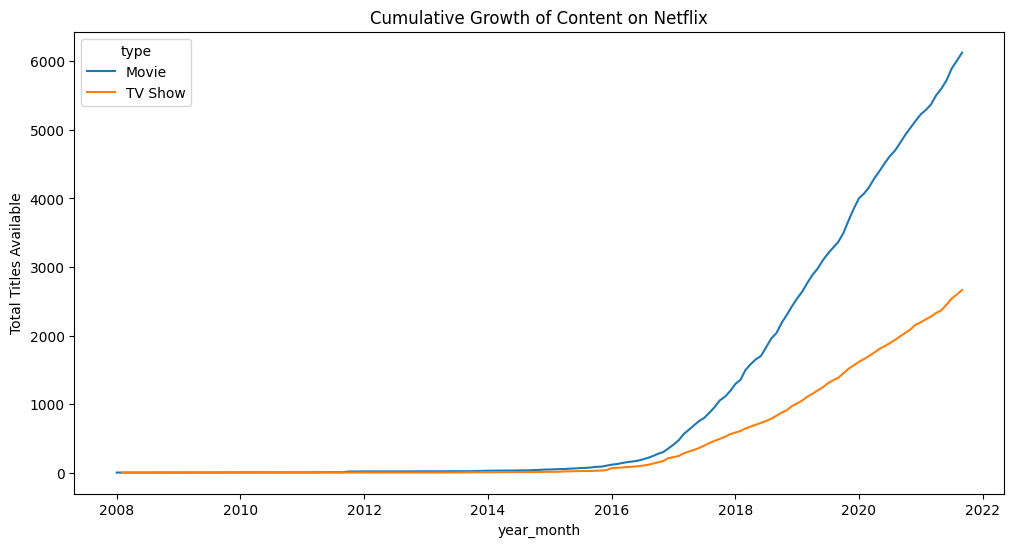

In [63]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=counts, x='year_month', y='cumulative_count', hue='type')
plt.title('Cumulative Growth of Content on Netflix')
plt.ylabel('Total Titles Available')
plt.show()